## 3. Number of arms per com events

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import starbars
from spyglass.shijiegu.changeOfMind_remote_interval import load_remote_animal
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_figures.figure3d import find_theta_dynamics_animals
from spyglass.shijiegu.changeOfMind_figures.dynamic_home_arm import (return_num_of_arms,
    return_meta_data, GLM_max_proportion, model2numbers, violin_plot)

[2026-05-02 16:42:29,674][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[16:42:44][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:42:44][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:42:44][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:42:44][WARNING] Spyglass: Deprecation: this class has b

In [3]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

# encoding_set = 'all_maze'
# classifier_param_name = 'default_decoding_gpu_4armMaze'

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']#'20231111']
seq_animals[animal] = 'rev2'

parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
hpd = False

local_parameter = f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"
remote_parameter = f"dur_{minimum_duration_remote}_sum_{min_posterior}"

### Home versus outer well

In [55]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="ephys_correctness")

[2026-04-27 09:31:38,491][WARNING]: Reconnecting to MySQL server.
[09:31:38][INFO] Spyglass: Starting {'export_id': 95}
INFO:spyglass:Starting {'export_id': 95}


In [100]:
success = {}
for animal in ["eliot","molly","lewis","klein","julio"]: 
    (num_of_arms, remote_time_spent,
     contain_long_theta, contain_home,
     remote_arm_content, remote_trial_infos,
     rewards) = return_num_of_arms(animal, list_of_days_animals[animal], sd = sd)

    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_count_{animal}_{sd}'
    data = {"num_of_arms": num_of_arms,
            "contain_home": contain_home,
            "remote_time_spent":remote_time_spent,
            "contain_long_theta": contain_long_theta,
            "remote_arm_content": remote_arm_content,
            "rewards": rewards,
            "remote_trial_infos": remote_trial_infos}
    file_path = output_folder + '.pkl'
    with open(file_path, 'wb') as file:
        print("data saved to " + file_path)
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    success[animal] = 1

eliot20221018_.nwb


[2026-04-27 19:34:51,612][WARNING]: Skipped checksum for file with hash: ef8155f2-8dbf-0e5f-fd9b-bfd518ff8cb9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_JTA96Y5GF2.nwb
[19:34:57][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-04-27 19:34:57,356][WARNING]: Skipped checksum for file with hash: d1b53fd3-0aa8-7a57-ebbe-65effe7b4587, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_WGJEY8F8R0.nwb
[2026-04-27 19:34:57,367][WARNING]: Skipped checksum for file with hash: d1b53fd3-0aa8-7a57-ebbe-65effe7b4587, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_WGJEY8F8R0.nwb
[2026-04-27 19:34:57,378][WARNING]: Skipped checksum for file with hash: d1b53fd3-0aa8-7a57-ebbe-65ef

No triggered decode found for  {'nwb_file_name': 'eliot20221018_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_max_segment_run_time_2_state'}


[2026-04-27 19:34:57,693][WARNING]: Skipped checksum for file with hash: f32655e8-bec3-ab1e-dce8-cc978f4aee2a, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_GWCJBJU5RE.nwb
[19:35:03][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-04-27 19:35:03,127][WARNING]: Skipped checksum for file with hash: dd219de2-dd5b-9f35-d1a3-d4881435075f, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_E9PB9YPSWH.nwb
[2026-04-27 19:35:03,137][WARNING]: Skipped checksum for file with hash: dd219de2-dd5b-9f35-d1a3-d4881435075f, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_E9PB9YPSWH.nwb
[2026-04-27 19:35:03,147][WARNING]: Skipped checksum for file with hash: dd219de2-dd5b-9f35-d1a3-d488

remote_interval_identities [0 4]


...

parsing multiple change of mind
outer_arms_after [9 7]
do_not_consider_arms None
remote_interval_identities [0 0 0]
parsing multiple change of mind
outer_arms_after [7]
do_not_consider_arms None
parsing multiple change of mind
outer_arms_after [7]
do_not_consider_arms None
parsing multiple change of mind
outer_arms_after [7]
do_not_consider_arms None
remote_interval_identities [3 3]


[19:59:43][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-04-27 19:59:43,909][WARNING]: Skipped checksum for file with hash: 58b13fef-e456-ed7e-1d54-b2a4f421a01f, and path: /stelmo/nwb/analysis/julio20230810/julio20230810_1M5066DGJ1.nwb
[2026-04-27 19:59:43,919][WARNING]: Skipped checksum for file with hash: 58b13fef-e456-ed7e-1d54-b2a4f421a01f, and path: /stelmo/nwb/analysis/julio20230810/julio20230810_1M5066DGJ1.nwb
[2026-04-27 19:59:43,930][WARNING]: Skipped checksum for file with hash: 58b13fef-e456-ed7e-1d54-b2a4f421a01f, and path: /stelmo/nwb/analysis/julio20230810/julio20230810_1M5066DGJ1.nwb
[2026-04-27 19:59:43,937][WARNING]: Skipped checksum for file with hash: 58b13fef-e456-ed7e-1d54-b2a4

parsing multiple change of mind
outer_arms_after [9]
do_not_consider_arms None
parsing multiple change of mind
outer_arms_after [9]
do_not_consider_arms None
julio20230811_.nwb
No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 2, 'proportion': 0.1, 'parameter': 'params_both_max_segment_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_max_segment_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 6, 'proportion': 0.1, 'parameter': 'params_both_max_segment_run_time_2_state'}


[2026-04-27 19:59:44,322][WARNING]: Skipped checksum for file with hash: 02c74df8-9eec-1382-1e39-81d823fc0a38, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_EHUTGPRCXX.nwb
[19:59:53][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-04-27 19:59:53,304][WARNING]: Skipped checksum for file with hash: 0c2c1874-1a73-9755-fa77-283a9cf0317e, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_ZS628HNU00.nwb
[2026-04-27 19:59:53,314][WARNING]: Skipped checksum for file with hash: 0c2c1874-1a73-9755-fa77-283a9cf0317e, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_ZS628HNU00.nwb
[2026-04-27 19:59:53,324][WARNING]: Skipped checksum for file with hash: 0c2c1874-1a73-9755-fa77-283a

remote_interval_identities [4 4]
parsing multiple change of mind
outer_arms_after [8 7]
do_not_consider_arms None
remote_interval_identities [0]
parsing multiple change of mind
outer_arms_after [7]
do_not_consider_arms None
data saved to /stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_count_julio_5.pkl


In [4]:
success

NameError: name 'success' is not defined

In [57]:
ExportSelection().stop_export(**paper_key, analysis_id="ephys_correctness")

In [98]:
# 'lewis20240105_.nwb','02_Rev2Session1',trialID = 70.
# Statescript outer well poke does not match the time from linear position, data corruption

### Plot histogram of number of arms of replayed

In [5]:
num_of_arms = {}
contain_home = {}
contain_long_theta = {}
time_spent = {}
rewards = {}

for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_count_{animal}_{sd}'
    file_path = output_folder + '.pkl'

    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    num_of_arms[animal] = data["num_of_arms"]
    contain_home[animal] = data["contain_home"]
    contain_long_theta[animal] = data["contain_long_theta"]
    time_spent[animal] = data["remote_time_spent"]
    rewards[animal] = data["rewards"]
    

In [16]:
for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    num_of_arms_ = np.array(num_of_arms[animal])
    no_event = num_of_arms_[num_of_arms_ == 0]
    long_event = np.array(contain_long_theta[animal])
    num_of_arms_[long_event > 0] -= 1
    
    print(animal, len(no_event), len(long_event[long_event > 0]), len(num_of_arms_[num_of_arms_ > 0]))

molly 88 39 23
eliot 227 27 39
julio 127 15 26
klein 207 91 141
lewis 228 116 98


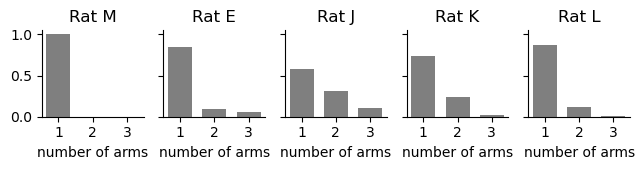

In [102]:
# excludes the current arm animal is in
animals = ["molly", "eliot", "julio", "klein", "lewis"]

x = [1,2,3,4]
fig, axes = plt.subplots(1,len(animals), figsize=(1.3*len(animals), 1.8), sharey = True)
animal_ind = 0
for animal in animals:
    data1 = np.array(num_of_arms[animal])
    data_local = np.array(contain_long_theta[animal]) > 0
    data_home = np.array(contain_home[animal]) > 0
    data1[data_local] -= 1
    data1[data_home] -= 1
    ind = data1 > 0

    
    data1 = data1[ind]
    axes[animal_ind].hist(data1, color = "k", alpha = 0.5, rwidth=0.7,
                          weights = np.ones_like(data1)/len(data1), bins = x)

    axes[animal_ind].set_xticks(np.array(x[:-1]) + 0.5)
    axes[animal_ind].set_xticklabels(np.array(x[:-1]))
    axes[animal_ind].set_xlabel("number of arms")
    axes[animal_ind].set_title(f"Rat {animal[0].upper()}")
    axes[animal_ind].spines['top'].set_visible(False)
    axes[animal_ind].spines['right'].set_visible(False)
    
    animal_ind += 1
plt.tight_layout()

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/"
plt.savefig(file_path + f'histogram_of_remote_arm_rep_exluding_current_arm.pdf',bbox_inches='tight')

### Compare general occurence with home and those without home

In [109]:
sd = 6

In [110]:
def mean_sd_err_p(arr):
    p = np.mean(arr)
    N = len(arr)
    std = np.sqrt(p * (1-p) / N)
    return p, std

def mean_sd_err(arr):
    p = np.mean(arr)
    std = np.std(arr)/np.sqrt(len(arr))
    return p, std
    
from spyglass.shijiegu.changeOfMind import nodes, color_by_rat

In [111]:
num_of_arms = {}
contain_home = {}
contain_long_theta = {}
time_spent = {}
rewards = {}

for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_count_{animal}_{sd}'
    file_path = output_folder + '.pkl'

    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    num_of_arms[animal] = data["num_of_arms"]
    contain_home[animal] = data["contain_home"]
    contain_long_theta[animal] = data["contain_long_theta"]
    time_spent[animal] = data["remote_time_spent"]
    rewards[animal] = data["rewards"]
    

In [112]:
from scipy.stats import fisher_exact, ranksums

molly
molly: local extended: p value 0.0004151691231559068
molly: number of outer arms: p value 0.44103010818864724
molly
molly: home reward: p value 0.1504628809396653
eliot
eliot: local extended: p value 0.11785154318458464
eliot: number of outer arms: p value 0.0036751693949003813
eliot
eliot: home reward: p value 0.33622361846722176
julio
julio: local extended: p value 0.016436233283362526
julio: number of outer arms: p value 0.031792106250409846
julio
julio: home reward: p value 0.00139250812756081
klein
klein: local extended: p value 0.006421020039957091
klein: number of outer arms: p value 0.00024269473348326857
klein
klein: home reward: p value 0.6875388940902032
lewis
lewis: local extended: p value 0.004483023732813035
lewis: number of outer arms: p value 0.28865039256974945
lewis
lewis: home reward: p value 0.7335776432619189


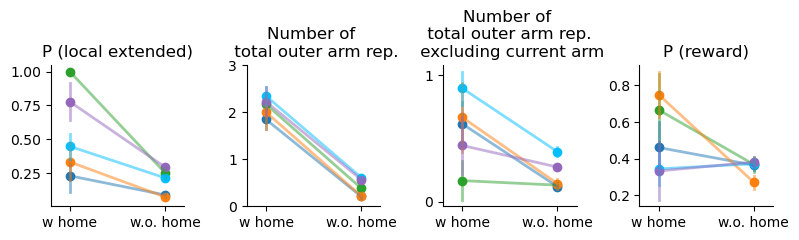

In [115]:
animals = ["molly", "eliot", "julio", "klein", "lewis"]

fig, axes = plt.subplots(1,4, figsize=(8, 2.5))
animal_ind = 0
for animal in animals:
    home = np.array(contain_home[animal]) > 0
    long_theta = np.array(contain_long_theta[animal])
    num = np.array(num_of_arms[animal])

    #### local extended long theta
    print(animal)
    data1 = long_theta[home]
    data2 = long_theta[~home]
    m1, sd1 = mean_sd_err_p(data1)
    m2, sd2 = mean_sd_err_p(data2)

    # do stats
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table, alternative = "less")
    p_value = res.pvalue
    print(f"{animal}: local extended: p value {p_value}")


    ax = axes[0]
    ax.plot([0, 1],[m1, m2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.scatter([0, 1],[m1, m2], color = color_by_rat[animal])
    ax.plot([0, 0],[m1 - sd1, m1 + sd1], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.plot([1, 1],[m2 - sd2, m2 + sd2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.set_title("P (local extended)")
    ax.set_xticks([0,1])
    ax.set_xlim([-0.2, 1.2])
    ax.set_xticklabels(["w home","w.o. home"])
    ax.spines[['right', 'top']].set_visible(False)


    #### Number of outer arms represented
    data1 = num[home]
    data2 = num[~home]
    m1, sd1 = mean_sd_err(data1)
    m2, sd2 = mean_sd_err(data2)

    

    ax = axes[1]
    ax.plot([0, 1],[m1, m2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.scatter([0, 1],[m1, m2], color = color_by_rat[animal])
    ax.plot([0, 0],[m1 - sd1, m1 + sd1], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.plot([1, 1],[m2 - sd2, m2 + sd2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.set_title("Number of \n total outer arm rep.")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1,2,3])
    ax.set_xlim([-0.2, 1.2])
    ax.set_xticklabels(["w home","w.o. home"])
    ax.spines[['right', 'top']].set_visible(False)

    #### Number of outer arms represented, excluding current
    num[long_theta > 0] -= 1
    num[home] -= 1
    data1 = num[home]
    data2 = num[~home]
    m1, sd1 = mean_sd_err(data1)
    m2, sd2 = mean_sd_err(data2)

    # do stats
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = ranksums(data1, data2, alternative = "greater")
    p_value = res.pvalue
    print(f"{animal}: number of outer arms: p value {p_value}")
    
    ax = axes[2]
    ax.plot([0, 1],[m1, m2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.scatter([0, 1],[m1, m2], color = color_by_rat[animal])
    ax.plot([0, 0],[m1 - sd1, m1 + sd1], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.plot([1, 1],[m2 - sd2, m2 + sd2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.set_title("Number of \n total outer arm rep. \n excluding current arm")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xlim([-0.2, 1.2])
    ax.set_xticklabels(["w home","w.o. home"])
    
    
    # print("p(local-extended) on trials with home rep. ", np.mean(data1))
    # print("p(local-extended) on trials without home", np.mean(data2))

    # print("Outer arm num represented on trials with home", np.mean(num[home]-1))
    # print("Outer arm num represented on trials without home", np.mean(num[~home]))

    # print("\n")
    ax.spines[['right', 'top']].set_visible(False)

    ###### Reward

    home = np.array(contain_home[animal]) > 0
    reward = np.array(rewards[animal]).astype("int")

    #### local extended long theta
    print(animal)
    data1 = reward[home]
    data2 = reward[~home]
    m1, sd1 = mean_sd_err_p(data1)
    m2, sd2 = mean_sd_err_p(data2)

    # do stats
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table, alternative = "less")
    p_value = res.pvalue
    print(f"{animal}: home reward: p value {p_value}")


    ax = axes[3]
    ax.plot([0, 1],[m1, m2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.scatter([0, 1],[m1, m2], color = color_by_rat[animal])
    ax.plot([0, 0],[m1 - sd1, m1 + sd1], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.plot([1, 1],[m2 - sd2, m2 + sd2], color = color_by_rat[animal], linewidth = 2, alpha = 0.5)
    ax.set_title("P (reward)")
    ax.set_xticks([0,1])
    ax.set_xlim([-0.2, 1.2])
    ax.set_xticklabels(["w home","w.o. home"])
    ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout() 
file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/home_vs_nohome.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")
   

## End here